# Atelier Seaborn

## Contexte 
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT. 
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression, 
la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure. 
Après avoir utilisé NumPy pour manipuler les données numériques, Pandas pour importer, nettoyer 
et analyser le dataset et Matplotlib pour réaliser des visualisations, l'étape suivante consiste à se 
servir de Seaborn pour réaliser une analyse exploratoire plus riche des données. 

## Structure du projet 

### 1) Structurer le projet comme suit : 
atelier_seaborn_iot/ 
│ 
├── data/ 
│   
└── mesures_capteurs.csv 
│    
├── notebooks/ 
│   
└── atelier_seaborn_iot.ipynb
│ 
└── exports/ 
├── temperature.png 
├── temperature.pdf  
└── ... 

### 2) Stocker le fichier fourni mesures_capteurs.csv dans le sous-dossier data 
### 3) Créer le notebook atelier_seaborn_iot.ipynb 

In [17]:
%pip install ipykernel

Note: you may need to restart the kernel to use updated packages.


In [18]:
# Creation du fichier notebook dans le dossier notebooks
# %mkdir atelier_seaborn_iot.ipynb

### 4) Installer et importer seaborn, matplotlib, pandas, numpy 

In [19]:
# Installation (si besoin, décommenter)
# !pip install pandas numpy matplotlib seaborn

#%pip install numpy pandas matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", rc={"figure.figsize": (10, 6)})
%matplotlib inline

**style="whitegrid"** définit l'apparence (fond blanc, grille légère, couleurs par défaut, etc.).

**rc** (pour "runtime configuration") permet de passer des réglages supplémentaires à matplotlib via seaborn. "figure.figsize": (10, 6) fixe la taille par défaut de chaque figure à 10 (largeur) sur 6 (hauteur), en pouces.

### 5) Importer mesures_capteurs.csv dans le dataframe df 

**Pour importer le fichier csv dans le dataframe df il faut:**
Charge le CSV dans un DataFrame pandas (tableau exploitable). Le ../ remonte d'un dossier depuis notebooks/ pour aller chercher data/.

In [20]:
df = pd.read_csv("../data/mesures_capteurs.csv")
#df.head() affiche les 5 premières lignes, pour vérifier que l'import est correct.
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


### 6) Vérifier le contenu du dataframe df 

In [21]:
#df.info() Structure du tableau : colonnes, types, valeurs non-nulles par colonne.
df.info()
print("_________________________________________________________________________________")
#df.isna().sum() Nombre de valeurs manquantes par colonne.
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB
_________________________________________________________________________________


id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

In [22]:
#df.describe() Statistiques des colonnes numériques : moyenne, min, max, quartiles.
df.describe()

,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


## Partie 1 – Distribution d'une variable avec histplot()

**Objectif :** Visualiser comment les valeurs de température se répartissent : autour de quelle valeur elles sont concentrées, si la distribution est symétrique, et s'il y a des valeurs extrêmes.

### 1) Afficher la distribution des températures

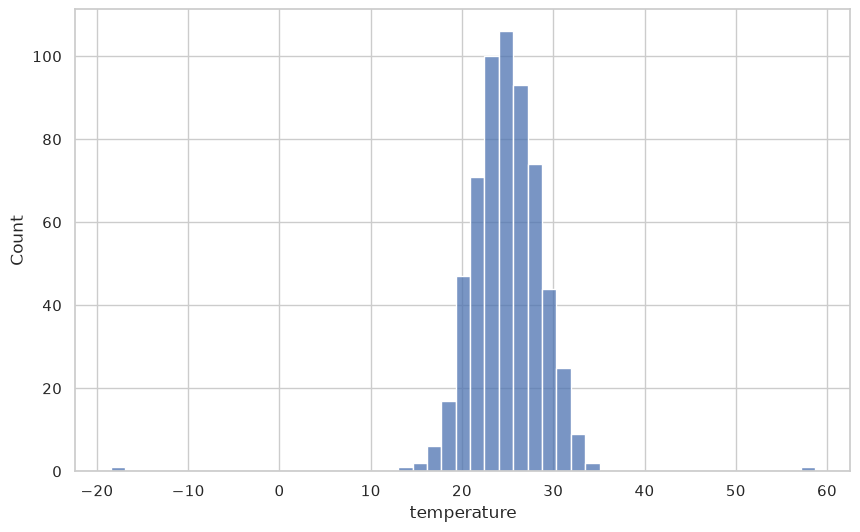

In [23]:
sns.histplot(data=df, x="temperature")
plt.show()

**data=df :** le DataFrame source

**x="temperature" :** la colonne à analyser

Seaborn découpe automatiquement les valeurs en "classes" (bins) et affiche une barre par classe, dont la hauteur correspond au nombre de mesures dans cette classe

### 2) Autour de quelle valeur les températures sont concentrées ?

In [24]:
print(df["temperature"].mean())
print(df["temperature"].median())

24.87831385642738
24.86


Les températures se concentrent principalement entre 20 et 30 °C, avec une moyenne de 24,88 °C et une médiane de 24,86 °C. 

Ces deux valeurs étant très proches, cela confirme que le pic de la distribution se situe bien autour de 25 °C.

###  3) La distribution semble-t-elle symétrique ? 

La distribution semble légèrement asymétrique : la majorité des températures sont concentrées autour de 25 °C, mais on observe quelques valeurs très faibles qui s'écartent nettement de ce groupe principal, avec très peu d'observations dans cette zone. 

Cela crée une traîne (queue) vers la gauche , ce qui rend la distribution non parfaitement symétrique.

In [25]:
df["temperature"].skew()

np.float64(-1.0470722374889554)

Le résultat est négatif, ça confirme une asymétrie vers la gauche comme on l'as observé.

### 4) Existe-t-il des valeurs extrêmes ? 

In [26]:
Q1 = df["temperature"].quantile(0.25)
Q3 = df["temperature"].quantile(0.75)
IQR = Q3 - Q1

borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

outliers = df[(df["temperature"] < borne_basse) | (df["temperature"] > borne_haute)]
print(f"Bornes : [{borne_basse:.2f}, {borne_haute:.2f}]")
print(f"Nombre de valeurs extrêmes : {len(outliers)}")
outliers

Bornes : [15.51, 34.33]
Nombre de valeurs extrêmes : 5


,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
43,M0575,2026-01-28 22:00:00,C011,B004,34.72,57.50,1008.94,266.22,ALERTE
245,M0127,2026-01-10 06:00:00,C007,B003,14.11,145.00,1032.36,169.57,ERREUR
258,M0223,2026-01-14 06:00:00,C007,B003,15.49,47.96,1006.34,124.90,OK
487,M0538,2026-01-27 09:00:00,C010,B004,-18.50,66.27,1012.49,312.92,ERREUR
502,M0048,2026-01-06 23:00:00,C012,B004,58.70,81.51,1026.79,271.92,ERREUR


**Sur les 5 valeurs extrêmes détectées :**

4 sur 5 sont associées à un état anormal du capteur (ALERTE ou ERREUR), ce qui suggère que ces températures extrêmes ne sont pas de simples variations naturelles, mais plutôt des dysfonctionnements de capteurs.

On trouve à la fois des valeurs anormalement basses (-18,50 °C, 14,11 °C) et anormalement hautes (58,70 °C, 34,72 °C) — ce qui explique pourquoi la distribution a une traîne des deux côtés, mais surtout vers la gauche comme vu avec le skewness.

Ces valeurs se concentrent surtout sur les bâtiments B003 et B004, notamment via les capteurs C007, C010, C011, C012.

Un seul outlier (15,49 °C) est marqué OK, ce qui suggère qu'il s'agit peut-être d'une vraie mesure basse plutôt que d'une anomalie technique.

### 5) Modifier le nombre de classes 

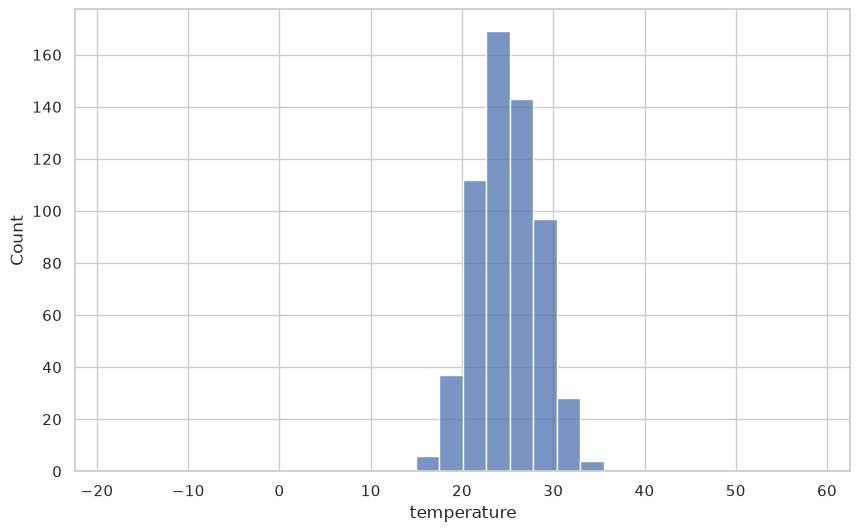

In [27]:
sns.histplot(data=df, x="temperature", bins=30)
plt.show()

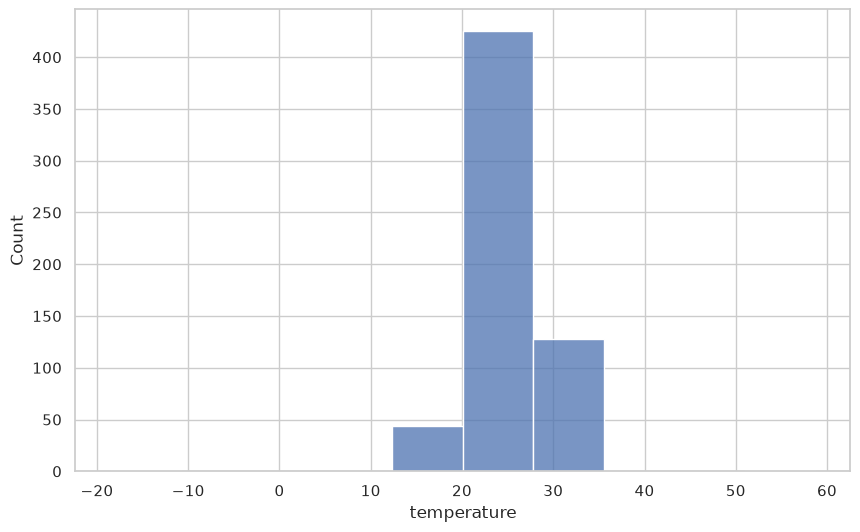

In [28]:
sns.histplot(data=df, x="temperature", bins=10)
plt.show()

Avec 10 bins, l'histogramme est très lissé : on ne distingue plus que 3 grandes barres, ce qui masque les détails de la distribution (les valeurs extrêmes en particulier disparaissent visuellement, noyées dans les classes larges).

Avec 30 bins, on obtient 8 barres visibles, ce qui donne plus de détail sur la forme de la distribution — mais les petites barres correspondant aux valeurs extrêmes (visibles dans l'histogramme par défaut) ne sont plus visibles non plus.

### 6) Afficher la distribution des températures par bâtiment

**hue** sert à découper les données par catégorie en utilisant une couleur différente pour chaque groupe.

**multiple="stack"** Ce paramètre contrôle comment les 4 distributions sont affichées les unes par rapport aux autres, une fois qu'on a déjà utilisé hue.

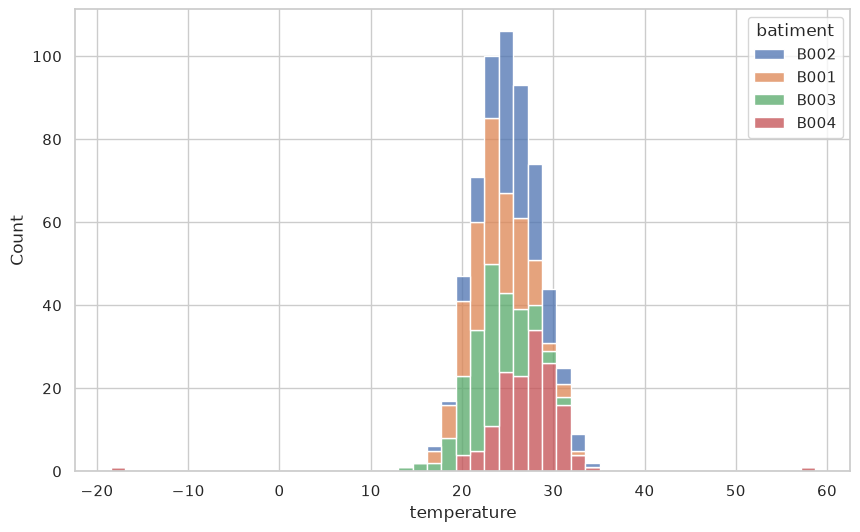

In [29]:
sns.histplot(data=df, x="temperature", hue="batiment", multiple="stack")
plt.show()